       ville  age  salaire   tele
0      Paris   30    42000   True
1       Lyon   25    38000  False
2      Paris   45    65000   True
3  Marseille   28    35000  False
4       Lyon   31    41000   True

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ville    6 non-null      object
 1   age      6 non-null      int64 
 2   salaire  6 non-null      int64 
 3   tele     6 non-null      bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 282.0+ bytes
None

        ville        age       salaire  tele
count       6   6.000000      6.000000     6
unique      3        NaN           NaN     2
top     Paris        NaN           NaN  True
freq        3        NaN           NaN     4
mean      NaN  30.166667  41833.333333   NaN
std       NaN   7.985403  12155.931337   NaN
min       NaN  22.000000  30000.000000   NaN
25%       NaN  25.750000  35750.000000   Na

<Axes: title={'center': 'Salaire moyen par ville'}, xlabel='ville'>

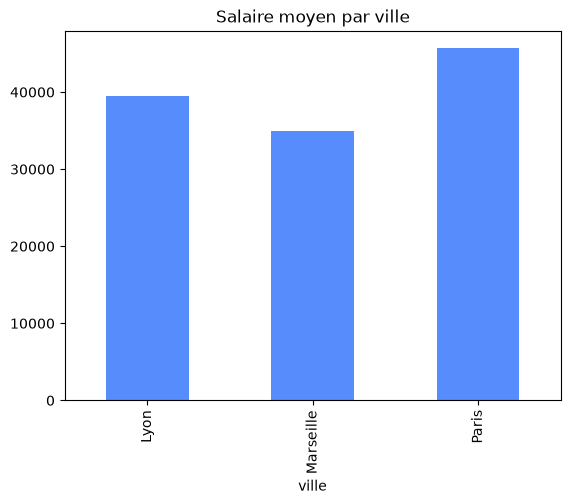

In [1]:
# Versions testées : python 3.11, pandas 2.x
import pandas as pd
import numpy as np

# Petit dataset bidon
df = pd.DataFrame({
    "ville":   ["Paris", "Lyon", "Paris", "Marseille", "Lyon", "Paris"],
    "age":     [30, 25, 45, 28, 31, 22],
    "salaire": [42000, 38000, 65000, 35000, 41000, 30000],
    "tele":    [True, False, True, False, True, True],
})

# Inspection
print(df.head())
print()
print(df.info())
print()
print(df.describe(include="all"))

# Filtrage + sélection
print()
print(df[df["age"] > 28][["ville", "salaire"]])

# Groupby
print()
print(df.groupby("ville")["salaire"].mean().round(0))

# Petite visualisation (nécessite matplotlib)
df.groupby("ville")["salaire"].mean().plot.bar(title="Salaire moyen par ville")

In [17]:
URL = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df_penguins = pd.read_csv(URL)

# Combien de lignes et de colonnes ? Quelles sont les colonnes ?
print(f"Lignes : {df_penguins.shape[0]}, Colonnes: {df_penguins.shape[1]}")
print(df_penguins.columns.tolist())

# Combien de valeurs manquantes par colonne ?
print(df_penguins.isna().sum())

Lignes : 344, Colonnes: 8
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [16]:
# Quelle est la masse corporelle moyenne (body_mass_g) ? La médiane ?

print(f"Moyenne masse corporelle: {df_penguins['body_mass_g'].mean().round(1)}g")
print(f"Médiane masse corporelle: {df_penguins['body_mass_g'].median().round(1)}g")

Moyenne masse corporelle: 4201.8g
Médiane masse corporelle: 4050.0g


In [20]:
# Quelle est la masse moyenne par espèce (species) ?
print("Moyenne masse corporelle par espèce :")
print(df_penguins.groupby('species')['body_mass_g'].mean().round(1))

Moyenne masse corporelle par espèce :
species
Adelie       3700.7
Chinstrap    3733.1
Gentoo       5076.0
Name: body_mass_g, dtype: float64


In [22]:
# Quelle est la masse moyenne par espèce et par sexe (croisé)
print("Moyenne masse corporelle par espèce et par sexe:")
print(df_penguins.groupby(['species','sex'])['body_mass_g'].mean().round(1))

Moyenne masse corporelle par espèce et par sexe:
species    sex   
Adelie     female    3368.8
           male      4043.5
Chinstrap  female    3527.2
           male      3939.0
Gentoo     female    4679.7
           male      5484.8
Name: body_mass_g, dtype: float64


In [29]:
# Crée une colonne is_large qui vaut True si body_mass_g > 4500.
df_penguins["is_large"] = df_penguins["body_mass_g"] > 4500

# Quelle est la proportion de pingouins « larges » par espèce ?
print((df_penguins.groupby('species')['is_large'].mean() * 100).round(1))

species
Adelie        4.6
Chinstrap     2.9
Gentoo       85.5
Name: is_large, dtype: float64


<Axes: title={'center': 'Masse moyenne par espèce'}, xlabel='species'>

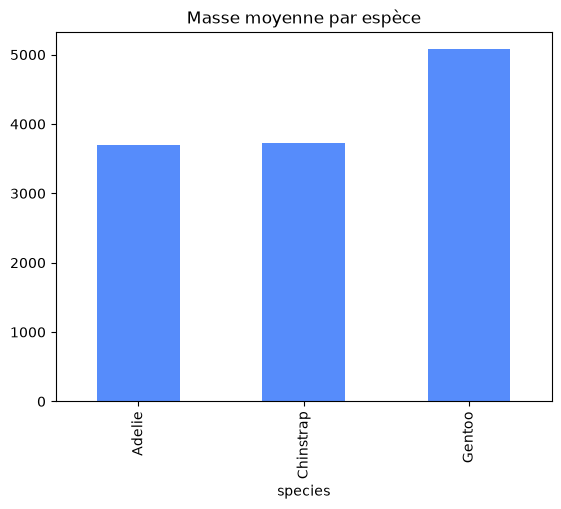

In [30]:
# Produis un graphique simple : un barchart de la masse moyenne par espèce.

df_penguins.groupby("species")["body_mass_g"].mean().plot.bar(title="Masse moyenne par espèce")
